José Herrera Ortiz - Universidad Pontificia Comillas ICAI

# Task 2: Regression

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from utils_project import (
    load_data,
    get_project_variables,
    build_regression_data,
    split_feature_types,
    create_preprocessor
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

Load data and build regression dataset

In [2]:
df = load_data("../data/rendimiento_estudiantes.csv")
variables = get_project_variables(df)

X_reg, y_reg = build_regression_data(df, variables)

print("Regression target:", variables["regression_target"])
print("X_reg shape:", X_reg.shape)
print("y_reg shape:", y_reg.shape)

Regression target: nota_media_2sem
X_reg shape: (4424, 30)
y_reg shape: (4424,)


Check leakage related design

The regression task aims to predict the student's second-semester average grade (`nota_media_2sem` in the renamed dataset). Following the project statement, variables from the second semester that would introduce data leakage are excluded from the predictor set. Therefore, the regression model is built only from entry variables, socioeconomic and macroeconomic context, and first-semester academic performance.

In [3]:
print("Regression target:", variables["regression_target"])
print("\nFeatures used for regression:")
print(variables["regression_features"])

print("\nExcluded features due to leakage:")
print(variables["regression_excluded_features"])

Regression target: nota_media_2sem

Features used for regression:
['estado_civil', 'nacionalidad', 'genero', 'edad_al_matricularse', 'desplazado', 'internacional', 'necesidades_educativas_especiales', 'modo_solicitud', 'orden_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 'nota_cualificacion_previa', 'nota_admision', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'deudor', 'matricula_al_dia', 'becado', 'tasa_desempleo', 'tasa_inflacion', 'pib', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion']

Excluded features due to leakage:
['asignaturas_2sem_convalidadas', 'asignaturas_2sem_matriculadas', 'asignaturas_2sem_evaluadas', 'asignaturas_2sem_aprobadas', 'asignaturas_2sem_sin_evaluacion']


Train/test split

In [4]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train_reg.shape, y_train_reg.shape)
print("Test :", X_test_reg.shape, y_test_reg.shape)

Train: (3539, 30) (3539,)
Test : (885, 30) (885,)


Feature-type split and preprocessing

In [5]:
numeric_reg, categorical_reg = split_feature_types(X_train_reg)

print("Numeric features:", numeric_reg)
print("Categorical features:", categorical_reg)

preprocessor_reg = create_preprocessor(
    numeric_features=numeric_reg,
    categorical_features=categorical_reg,
    scale_numeric=True
)

print("Regression preprocessor created successfully.")

Numeric features: ['edad_al_matricularse', 'orden_solicitud', 'nota_cualificacion_previa', 'nota_admision', 'tasa_desempleo', 'tasa_inflacion', 'pib', 'asignaturas_1sem_convalidadas', 'asignaturas_1sem_matriculadas', 'asignaturas_1sem_evaluadas', 'asignaturas_1sem_aprobadas', 'nota_media_1sem', 'asignaturas_1sem_sin_evaluacion']
Categorical features: ['estado_civil', 'nacionalidad', 'genero', 'desplazado', 'internacional', 'necesidades_educativas_especiales', 'modo_solicitud', 'curso', 'asistencia_diurna_vespertina', 'cualificacion_previa', 'cualificacion_madre', 'cualificacion_padre', 'ocupacion_madre', 'ocupacion_padre', 'deudor', 'matricula_al_dia', 'becado']
Regression preprocessor created successfully.


## 1.1. Baseline model: Ridge

In [6]:
ridge_reg = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", Ridge(alpha=1.0))
])

ridge_reg.fit(X_train_reg, y_train_reg)
y_pred_ridge = ridge_reg.predict(X_test_reg)

Evaluate Ridge on test

In [7]:
print("=== Ridge Regression ===")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)))
print("R²  :", r2_score(y_test_reg, y_pred_ridge))

=== Ridge Regression ===
MAE : 1.5930707849847443
RMSE: 2.6441042484568125
R²  : 0.7417706372514918


## 1.2. Random Forest regressor

In [8]:
rf_reg = Pipeline([
    ("preprocessor", preprocessor_reg),
    ("model", RandomForestRegressor(
        n_estimators=400,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

Evaluate Random Forest on test

In [9]:
print("=== Random Forest Regressor ===")
print("MAE :", mean_absolute_error(y_test_reg, y_pred_rf_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)))
print("R²  :", r2_score(y_test_reg, y_pred_rf_reg))

=== Random Forest Regressor ===
MAE : 1.396682426863298
RMSE: 2.7076042878038593
R²  : 0.7292185796694681


## 2. Cross Validation (CV)

In [10]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

scoring_reg = {
    "neg_mae": "neg_mean_absolute_error",
    "neg_rmse": "neg_root_mean_squared_error",
    "r2": "r2"
}

models_reg = {
    "Ridge": ridge_reg,
    "RF_Regressor": rf_reg
}

cv_results_reg = []

for name, model in models_reg.items():
    scores = cross_validate(
        model,
        X_train_reg,
        y_train_reg,
        cv=cv,
        scoring=scoring_reg,
        n_jobs=-1
    )

    cv_results_reg.append({
        "model": name,
        "cv_mae_mean": -scores["test_neg_mae"].mean(),
        "cv_rmse_mean": -scores["test_neg_rmse"].mean(),
        "cv_r2_mean": scores["test_r2"].mean()
    })

cv_results_reg = pd.DataFrame(cv_results_reg).sort_values("cv_rmse_mean")
cv_results_reg.round(4)

,model,cv_mae_mean,cv_rmse_mean,cv_r2_mean
1,RF_Regressor,1.2729,2.4675,0.7726
0,Ridge,1.5723,2.6487,0.7389


Test result table

In [11]:
test_results_reg = pd.DataFrame([
    {
        "model": "Ridge",
        "test_mae": mean_absolute_error(y_test_reg, y_pred_ridge),
        "test_rmse": np.sqrt(mean_squared_error(y_test_reg, y_pred_ridge)),
        "test_r2": r2_score(y_test_reg, y_pred_ridge),
    },
    {
        "model": "RF_Regressor",
        "test_mae": mean_absolute_error(y_test_reg, y_pred_rf_reg),
        "test_rmse": np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
        "test_r2": r2_score(y_test_reg, y_pred_rf_reg),
    }
]).sort_values("test_rmse")

test_results_reg.round(4)

,model,test_mae,test_rmse,test_r2
0,Ridge,1.5931,2.6441,0.7418
1,RF_Regressor,1.3967,2.7076,0.7292


Final comparison table

In [12]:
final_results_reg = cv_results_reg.merge(test_results_reg, on="model", how="inner")

final_results_reg = final_results_reg[
    ["model", "cv_mae_mean", "cv_rmse_mean", "cv_r2_mean", "test_mae", "test_rmse", "test_r2"]
].sort_values("test_rmse")

final_results_reg.round(4)

,model,cv_mae_mean,cv_rmse_mean,cv_r2_mean,test_mae,test_rmse,test_r2
1,Ridge,1.5723,2.6487,0.7389,1.5931,2.6441,0.7418
0,RF_Regressor,1.2729,2.4675,0.7726,1.3967,2.7076,0.7292


## 3. Diagnostic plots

### 3.1. Real vs predicted

In [13]:
def plot_real_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    plt.plot(lims, lims, linestyle="--")
    plt.xlabel("True values")
    plt.ylabel("Predicted values")
    plt.title(title)
    plt.tight_layout()
    plt.show()

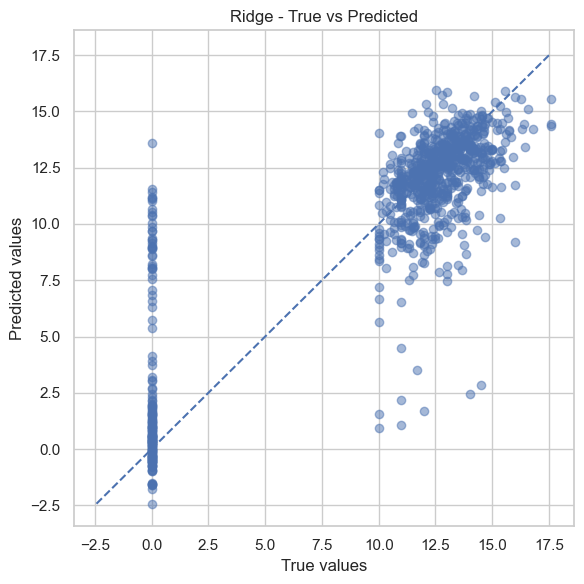

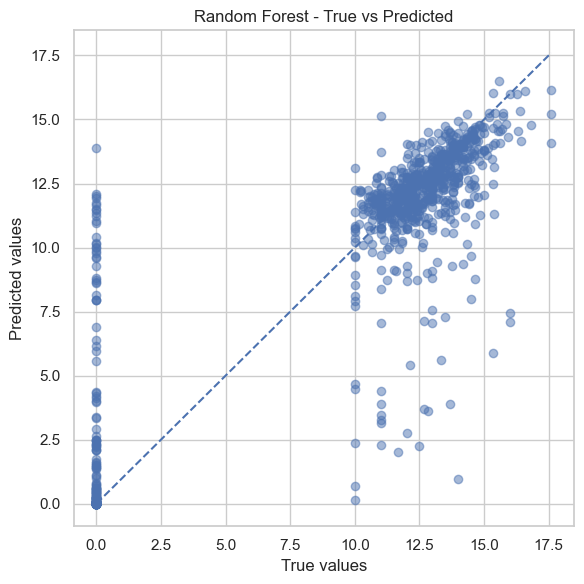

In [14]:
plot_real_vs_pred(y_test_reg, y_pred_ridge, "Ridge - True vs Predicted")
plot_real_vs_pred(y_test_reg, y_pred_rf_reg, "Random Forest - True vs Predicted")

### 3.2. Residuals

In [15]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(7, 4))
    sns.histplot(residuals, kde=True)
    plt.title(title)
    plt.xlabel("Residual")
    plt.tight_layout()
    plt.show()

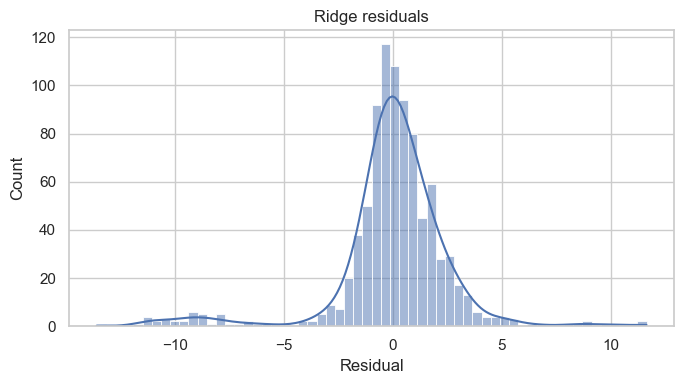

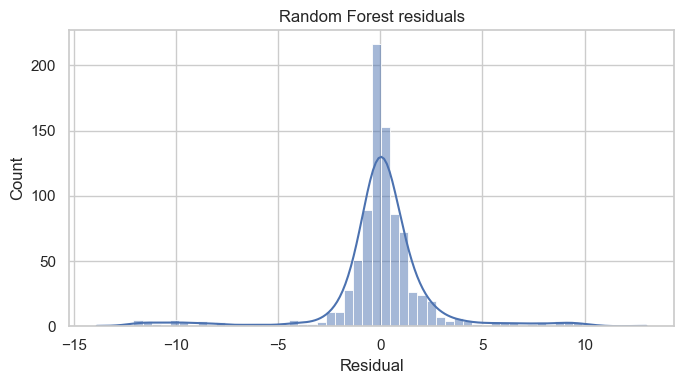

In [16]:
plot_residuals(y_test_reg, y_pred_ridge, "Ridge residuals")
plot_residuals(y_test_reg, y_pred_rf_reg, "Random Forest residuals")

Model interpretation

In [17]:
from utils_project import get_feature_names_from_preprocessor

In [18]:
feature_names_reg = get_feature_names_from_preprocessor(
    preprocessor=rf_reg.named_steps["preprocessor"],
    numeric_features=numeric_reg,
    categorical_features=categorical_reg
)

len(feature_names_reg)

243

In [19]:
rf_model = rf_reg.named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_names_reg,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

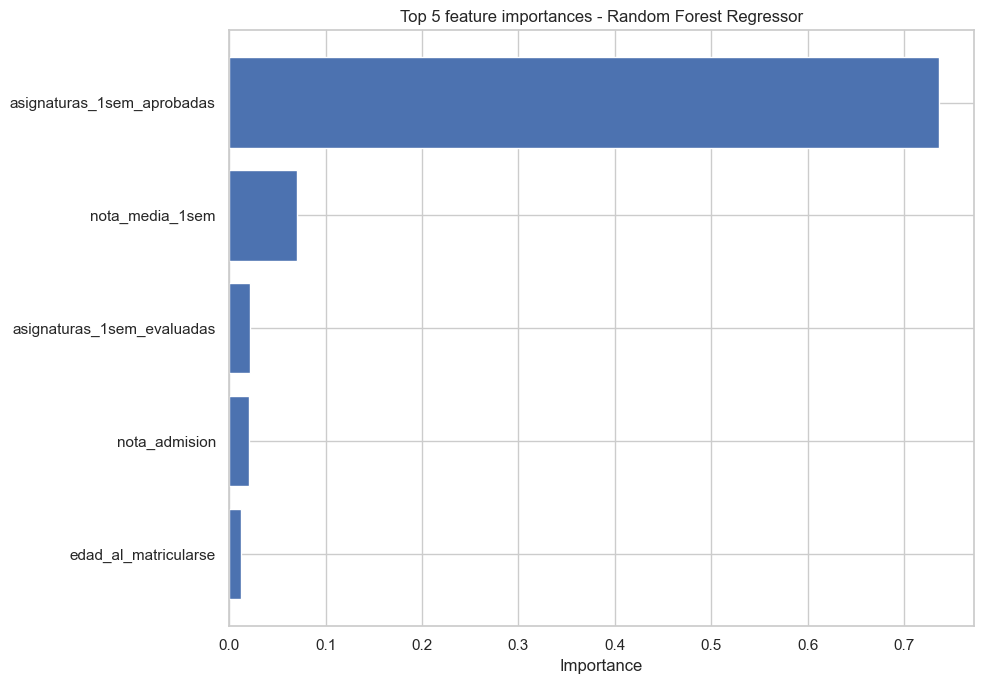

In [20]:
top_n = 5
top_importance_df = importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(10, 7))
plt.barh(top_importance_df["feature"], top_importance_df["importance"])
plt.title("Top 5 feature importances - Random Forest Regressor")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [21]:
importance_summary = importance_df.head(8).copy()
importance_summary["importance"] = importance_summary["importance"].round(4)
importance_summary

,feature,importance
10,asignaturas_1sem_aprobadas,0.7355
11,nota_media_1sem,0.0707
9,asignaturas_1sem_evaluadas,0.0212
3,nota_admision,0.0205
0,edad_al_matricularse,0.0127
2,nota_cualificacion_previa,0.0117
4,tasa_desempleo,0.0095
5,tasa_inflacion,0.0078
